# Model Training

This code loads the extracted feature dataframe and trains classification models on it.
It also evaluates the models.

NOTE:
EDA,
Rewrite Dataset part, include link
Performance of Sliding Window Object Detection
Title change
add Sample Input image

In [109]:
import numpy as np
import pandas as pd
import time
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_auc_score, roc_curve)
from sklearn.model_selection import GridSearchCV

In [110]:
# importing feature_df
feature_df = pd.read_csv('feature_df.csv')

In [111]:
feature_df.shape

(11550, 21)

In [112]:
feature_df.head()

,dissimilarity,correlation,homogeneity,contrast,ASM,energy,mean_r,std_r,skewness_r,kurtosis_r,...,Bin_1,Bin_2,Bin_3,Bin_4,Bin_5,Bin_6,Bin_7,Bin_8,Bin_9,class
0,18.923771,0.759237,0.085817,785.858455,0.000174,0.013178,4.656550,2.405307,0.180622,-0.618296,...,0.187731,0.181780,0.396916,0.611160,0.425304,0.252004,0.190915,0.175472,0.278398,1
1,13.545805,0.799017,0.110258,409.500687,0.000266,0.016306,4.614077,1.990894,0.426140,0.137922,...,0.097425,0.102240,0.387548,0.707688,0.480978,0.207758,0.117402,0.124675,0.154282,1
2,23.779350,0.539249,0.063523,1198.639625,0.000201,0.014193,4.495674,2.211519,0.346357,-0.239547,...,0.134946,0.187729,0.459671,0.632197,0.441393,0.235387,0.139046,0.124014,0.209935,1
3,16.856000,0.773274,0.081487,583.762113,0.000135,0.011633,4.486680,1.721655,0.628006,1.036629,...,0.063987,0.069037,0.335437,0.783070,0.468085,0.158973,0.077217,0.079065,0.091719,1
4,10.517836,0.451345,0.110380,212.400119,0.000769,0.027726,4.642310,2.485948,0.164132,-0.740309,...,0.236272,0.198469,0.389849,0.558390,0.450492,0.240997,0.193743,0.189805,0.305579,1


In [113]:
# Dataframe to store model evaluation metrics

columns = ['model_used', 'training_time(s)', 'Train_Accuracy', 'Test_Accuracy',
           'Precision', 'Recall', 'F1 Score', 'roc_auc_score']
eval_df = pd.DataFrame(columns=columns)

In [114]:
# Split the X and y Dataset into the Training set and Test set
from sklearn.model_selection import train_test_split

X = feature_df.drop(columns=['class']).values
y = feature_df['class'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20,
                                                    random_state=0, stratify=y)

In [115]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [116]:
def plot_roc_curve(true_y, y_prob):
    """
    plots the roc curve based of the probabilities
    """
    fpr, tpr, thresholds = roc_curve(true_y, y_prob)
    plt.plot(fpr, tpr)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')

In [117]:
# Utility function to evaluate model performance

def evaluate(model, y_train, y_test, train_time, model_name:str):
    y_pred = model.predict(X_test)
    train_pred = model.predict(X_train)
    train_accuracy = round(accuracy_score(y_train, train_pred), 3)
    test_accuracy = round(accuracy_score(y_test, y_pred), 3)
    precision = round(precision_score(y_test, y_pred), 3)
    recall = round(recall_score(y_test, y_pred), 3)
    f1 = round(f1_score(y_test, y_pred), 3)
    roc_auc = roc_auc_score(y_test, y_pred)

    print('Training time:', train_time, 's')
    print('Train accuracy:', train_accuracy)
    print('Test accuracy:', test_accuracy)
    print('Precision:', precision)
    print('Recall:', recall)
    print('F1 Score', f1)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print(f'ROC-AUC score: {roc_auc}')
    plot_roc_curve(y_test, y_pred)

    # creating evaluation dataframe entry
    eval_df.loc[len(eval_df)] = [model_name, round(train_time, 3),
                                 train_accuracy, test_accuracy,
                                 precision, recall, f1, round(roc_auc, 3)]


## Random Forest Classifier

Training time: 0.911895751953125 s
Train accuracy: 0.981
Test accuracy: 0.831
Precision: 0.816
Recall: 0.838
F1 Score 0.827
Confusion Matrix:
 [[988 210]
 [180 932]]
ROC-AUC score: 0.8314186714067812


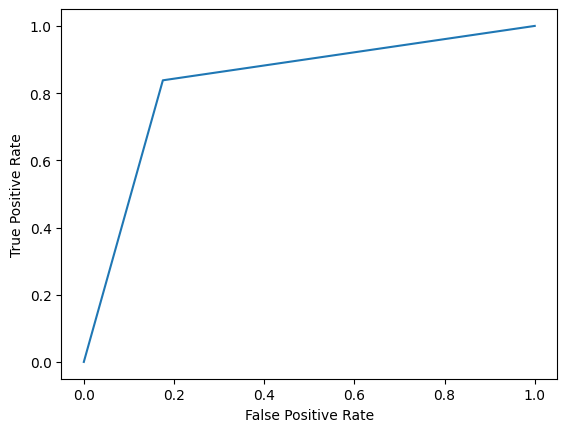

In [118]:
from sklearn.ensemble import RandomForestClassifier

# Create an instance of Random Forest Classifier
forest = RandomForestClassifier(max_depth=13, min_samples_split=2, n_estimators=200,
                                random_state=1, n_jobs=8)

train_start_time = time.time()

# Fit the model
forest.fit(X_train, y_train)

train_time = time.time() - train_start_time

evaluate(forest, y_train, y_test, train_time, "Random Forest Classifier")

## Support Vector Classifier

Training time: 1.5388171672821045 s
Train accuracy: 0.801
Test accuracy: 0.809
Precision: 0.798
Recall: 0.808
F1 Score 0.803
Confusion Matrix:
 [[971 227]
 [214 898]]
ROC-AUC score: 0.8090357430249456


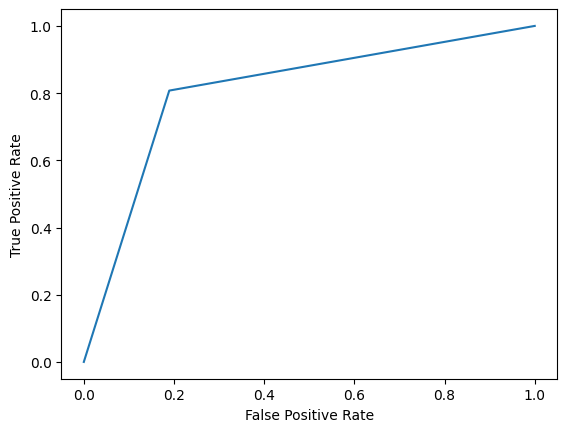

In [119]:
from sklearn.svm import SVC

# Training SVM model

train_start_time = time.time()

svm = SVC(kernel='linear')
svm.fit(X_train, y_train)

train_time = time.time() - train_start_time

evaluate(svm, y_train, y_test, train_time, "Support Vector Classifier")

## KNN Classifier

Training time: 0.002288818359375 s
Train accuracy: 0.851
Test accuracy: 0.79
Precision: 0.785
Recall: 0.777
F1 Score 0.781
Confusion Matrix:
 [[962 236]
 [248 864]]
ROC-AUC score: 0.7899917128067163


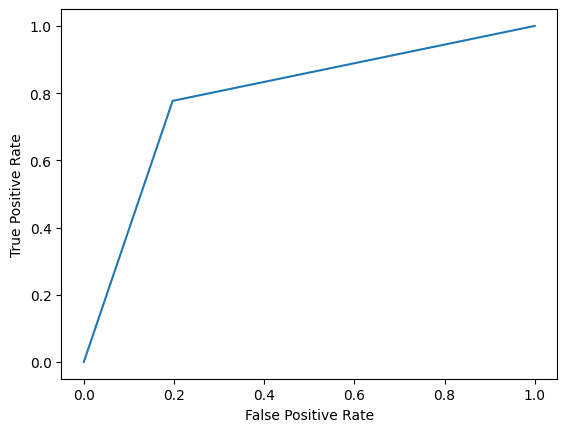

In [120]:
from sklearn.neighbors import KNeighborsClassifier

KNNclassifier = KNeighborsClassifier(n_neighbors=8 , metric='minkowski', p=2)

train_start_time = time.time()
KNNclassifier.fit(X_train, y_train)
train_time = time.time() - train_start_time

evaluate(KNNclassifier, y_train, y_test, train_time, "KNN Classifier")

## Logistic Regression

Training time: 0.960364818572998 s
Train accuracy: 0.798
Test accuracy: 0.81
Precision: 0.802
Recall: 0.804
F1 Score 0.803
Confusion Matrix:
 [[977 221]
 [218 894]]
ROC-AUC score: 0.809741355496571


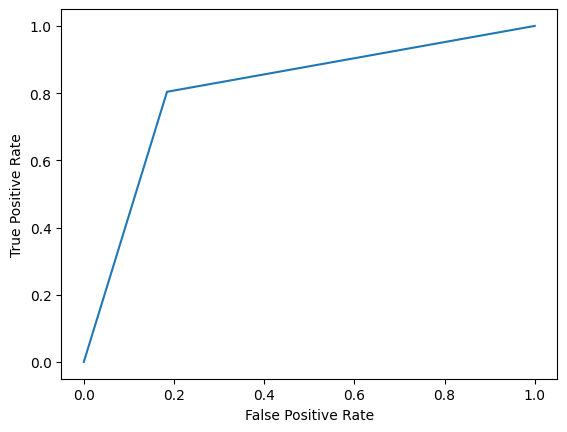

In [121]:
from sklearn import linear_model

logr = linear_model.LogisticRegression(max_iter=1000)

train_start_time = time.time()

logr.fit(X_train, y_train)

train_time = time.time() - train_start_time

evaluate(logr, y_train, y_test, train_time, "Logistic Regression")

In [122]:
eval_df

,model_used,training_time(s),Train_Accuracy,Test_Accuracy,Precision,Recall,F1 Score,roc_auc_score
0,Random Forest Classifier,0.912,0.981,0.831,0.816,0.838,0.827,0.831
1,Support Vector Classifier,1.539,0.801,0.809,0.798,0.808,0.803,0.809
2,KNN Classifier,0.002,0.851,0.790,0.785,0.777,0.781,0.790
3,Logistic Regression,0.960,0.798,0.810,0.802,0.804,0.803,0.810


# Saving trained models
import pickle

pickle.dump(forest, open('trained_models/RandomForestClassifier.sav', 'wb'))
pickle.dump(svm, open('trained_models/SupportVectorClassifier.sav', 'wb'))
pickle.dump(KNNclassifier, open('trained_models/KNNClassifier.sav', 'wb'))
pickle.dump(logr, open('trained_models/LogisticRegression.sav', 'wb'))

In [124]:
eval_df.to_csv("eval_df.csv", index=False)

# Testing

In [17]:
# TEST ONE IMAGE

mean_std_df = pd.read_csv('mean_std_df.csv')

def my_standard_scaler(features):
    scaled_features = []
    for i, value in enumerate(features):
        mean = mean_std_df.iat[i, 1]
        std = mean_std_df.iat[i, 2]
        scaled_features.append((value - mean) / std)
    return np.array(scaled_features)

import cv2
import Utilities

testimg = cv2.imread('/Users/sinner/Desktop/waste_only_images_all/0067.jpg')
testimg = cv2.cvtColor(testimg, cv2.COLOR_BGR2RGB)

# # Feature Scaling
features = my_standard_scaler(Utilities.get_features(testimg))

predicted_class = forest.predict(np.reshape(features, (1,-1)))
# predicted_class = forest.predict(features)
print(predicted_class)

[1.]


In [18]:
# TEST ALL WINDOWS

import cv2
import Utilities
import os

src_folder_path = '/Users/sinner/Desktop/images_to_scan'
dest_folder_path = '/Users/sinner/Desktop/scanning_output'


imgCount = 0

# iterating in source folder
for filename in os.listdir(src_folder_path):

    if not filename.endswith('.jpg'):
        continue

    print(f"Scanning {filename}")

    img = cv2.imread(os.path.join(src_folder_path, filename))

    window_list = Utilities.get_windows(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), 100, 100)

    print(f"no. of windows extracted: {len(window_list)}")
    for window in window_list:

        # Feature Scaling
        features = Utilities.get_features(window)
        features = my_standard_scaler(features)

        # predicted_class = loaded_model.predict(np.reshape(features, (1,-1)))
        predicted_class = forest.predict(np.reshape(features, (1,-1)))
        print(predicted_class)

        if predicted_class[0] == 1:
            imgCount += 1
            cv2.imwrite(os.path.join(dest_folder_path, f'{imgCount}.jpg'),
                        cv2.cvtColor(window, cv2.COLOR_RGB2BGR))

        print(imgCount)

Scanning 0001.jpg
no. of windows extracted: 527
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[0.]
0
[1.]
1
[1.]
2
[1.]
3
[1.]
4
[1.]
5
[1.]
6
[0.]
6
[0.]
6
[0.]
6
[0.]
6
[0.]
6
[0.]
6
[0.]
6
[0.]
6
[0.]
6
[0.]
6
[0.]
6
[0.]
6
[0.]
6
[0.]
6
[0.]
6
[0.]
6
[0.]
6
[0.]
6
[0.]
6
[0.]
6
[0.]
6
[0.]
6
[0.]
6
[0.]
6
[0.]
6
[0.]
6
[0.]
6
[0.]
6
[0.]
6
[0.]
6
[0.]
6
[0.]
6
[1.]
7
[1.]
8
[1.]
9
[1.]
10
[0.]
1

# GridSearchCV

In [59]:
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

# Create a Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42)

# Create a GridSearchCV object and fit it to the training data
grid_search = GridSearchCV(estimator=rf_classifier, param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Print the best parameters and the corresponding accuracy score
print("Best parameters found: ", grid_search.best_params_)
print("Best accuracy score: ", grid_search.best_score_)

# Evaluate the model on the training data
best_classifier = grid_search.best_estimator_
train_accuracy = best_classifier.score(X_train, y_train)
print("Accuracy on the test set: ", train_accuracy)

# Evaluate the model on the testing data
best_classifier = grid_search.best_estimator_
test_accuracy = best_classifier.score(X_test, y_test)
print("Accuracy on the test set: ", test_accuracy)

train_accuracy = best_classifier.score(X_train, y_train)
print("Accuracy on the train set: ", train_accuracy)

KeyboardInterrupt: 

In [12]:
from sklearn.svm import SVC

# Define the parameter grid to search over
param_grid = {
    'C': [0.1, 1.0, 10.0],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

# Create a Support Vector Classifier
svc_classifier = SVC(random_state=42)

# Create a GridSearchCV object and fit it to the training data
grid_search = GridSearchCV(estimator=svc_classifier, param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Print the best parameters and the corresponding accuracy score
print("Best parameters found: ", grid_search.best_params_)
print("Best accuracy score: ", grid_search.best_score_)

# Evaluate the model on the testing data
best_classifier = grid_search.best_estimator_
test_accuracy = best_classifier.score(X_test, y_test)
print("Accuracy on the test set: ", test_accuracy)

train_accuracy = best_classifier.score(X_train, y_train)
print("Accuracy on the train set: ", train_accuracy)

Best parameters found:  {'C': 10.0, 'gamma': 'scale', 'kernel': 'rbf'}
Best accuracy score:  0.8358225108225108
Accuracy on the test set:  0.8277056277056277
Accuracy on the train set:  0.8469696969696969


In [13]:
from sklearn.neighbors import KNeighborsClassifier

# Define the parameter grid to search over
param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

# Create a KNN Classifier
knn_classifier = KNeighborsClassifier()

# Create a GridSearchCV object and fit it to the training data
grid_search = GridSearchCV(estimator=knn_classifier, param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Print the best parameters and the corresponding accuracy score
print("Best parameters found: ", grid_search.best_params_)
print("Best accuracy score: ", grid_search.best_score_)

# Evaluate the model on the testing data
best_classifier = grid_search.best_estimator_
test_accuracy = best_classifier.score(X_test, y_test)
print("Accuracy on the test set: ", test_accuracy)

train_accuracy = best_classifier.score(X_train, y_train)
print("Accuracy on the train set: ", train_accuracy)

Best parameters found:  {'n_neighbors': 7, 'p': 1, 'weights': 'distance'}
Best accuracy score:  0.8122294372294373
Accuracy on the test set:  0.7991341991341991
Accuracy on the train set:  1.0
